In [73]:
# 1. Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [74]:
# Loading the Dataset
df = pd.read_csv("telecom_customer_churn_dataset.csv")

In [75]:
# Dataset Overview
df.head()

,customerID,gender,SeniorCitizen,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,PaymentMethod,Churn
0,CUST108575,NaN,0.0,46.0,yes,dsl,Two year,99.31,4503.37,Credit card,No
1,CUST103742,FEMALE,NaN,18.0,No,NaN,month-to-month,20.76,416.93,NaN,no
2,CUST106231,Female,NaN,34.0,NaN,No,month-to-month,22.53,709.87,NaN,Yes
3,CUST105723,male,0.0,45.0,NaN,dsl,Two year,52.79,1952.69,Credit card,no
4,CUST108987,male,NaN,55.0,No,No,Two year,29.91,1822.84,Electronic check,no


In [76]:
# Checking Dataset Shape
df.shape

(10200, 11)

In [77]:
# Viewing Column Names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'tenure', 'PhoneService',
       'InternetService', 'Contract', 'MonthlyCharges', 'TotalCharges',
       'PaymentMethod', 'Churn'],
      dtype='object')

In [78]:
# Inspecting Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       10200 non-null  object 
 1   gender           8153 non-null   object 
 2   SeniorCitizen    6868 non-null   float64
 3   tenure           10027 non-null  float64
 4   PhoneService     7581 non-null   object 
 5   InternetService  8212 non-null   object 
 6   Contract         10200 non-null  object 
 7   MonthlyCharges   9891 non-null   float64
 8   TotalCharges     9728 non-null   float64
 9   PaymentMethod    8064 non-null   object 
 10  Churn            10200 non-null  object 
dtypes: float64(4), object(7)
memory usage: 876.7+ KB


In [79]:
# Missing Value Analysis
df.isnull().sum()

customerID            0
gender             2047
SeniorCitizen      3332
tenure              173
PhoneService       2619
InternetService    1988
Contract              0
MonthlyCharges      309
TotalCharges        472
PaymentMethod      2136
Churn                 0
dtype: int64

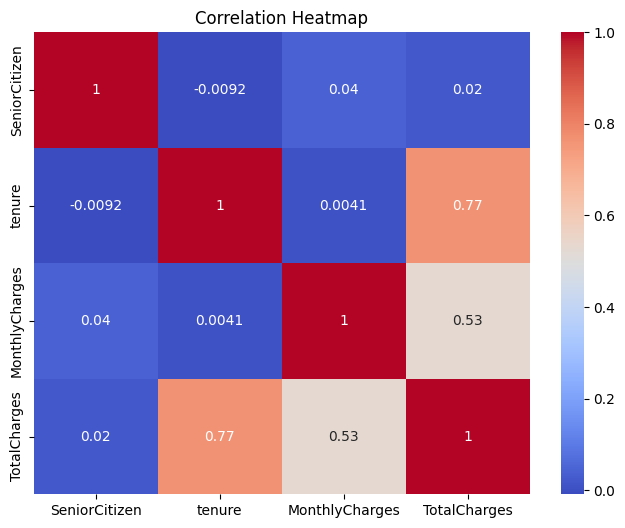

In [80]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [81]:
# Handling Missing Values
df = df.dropna()

In [82]:
# Removing Duplicate Records
df = df.drop_duplicates()

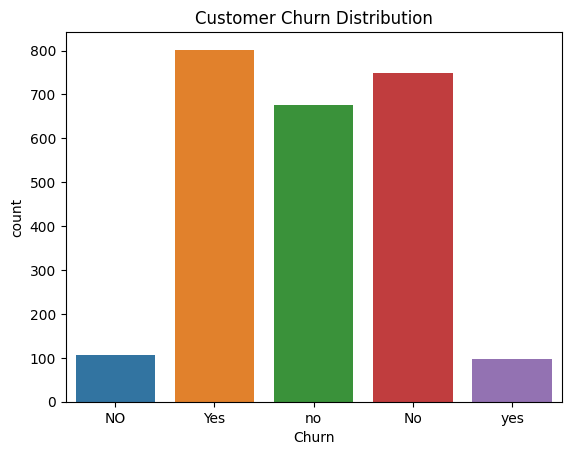

In [83]:
# Churn Distribution Analysis
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

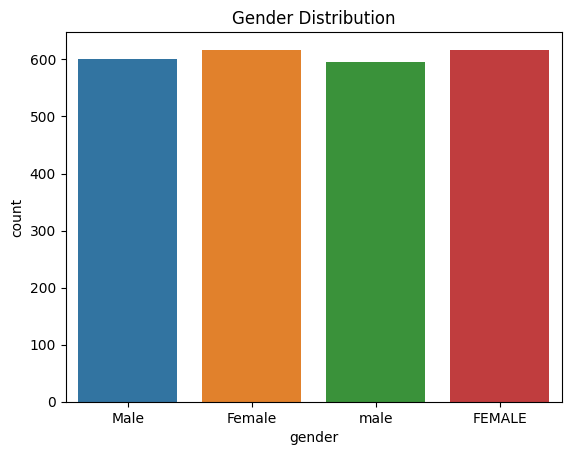

In [84]:
# Gender Distribution Analysis
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

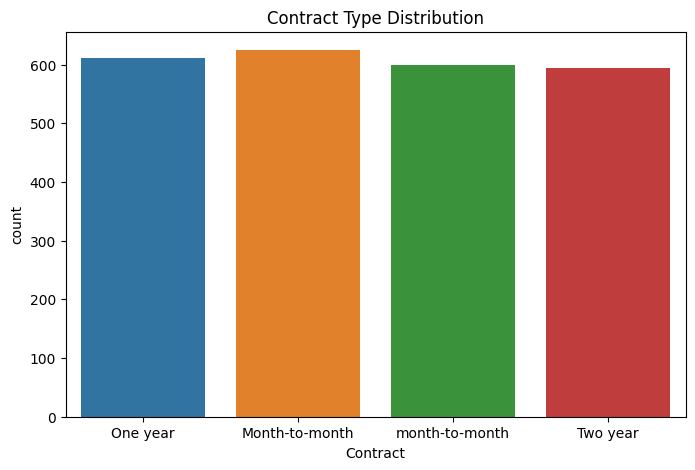

In [85]:
# Contract Type Analysis
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', data=df)
plt.title("Contract Type Distribution")
plt.show()

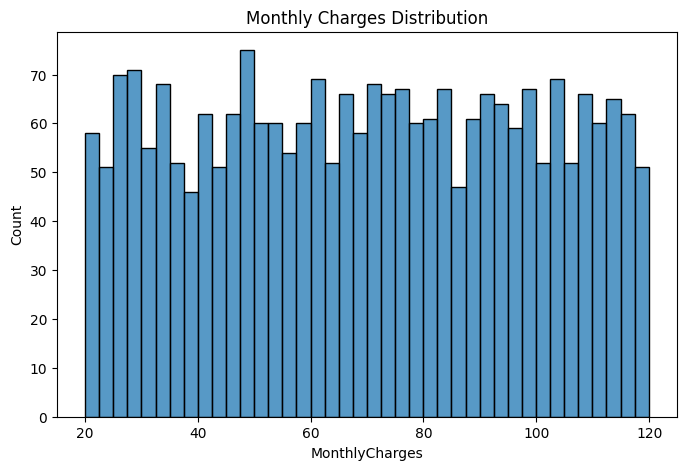

In [86]:
# Monthly Charges Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=40)
plt.title("Monthly Charges Distribution")
plt.show()

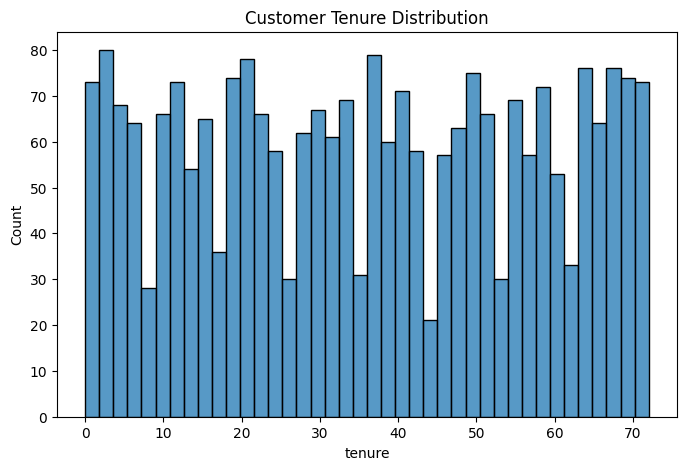

In [87]:
# Tenure Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=40)
plt.title("Customer Tenure Distribution")
plt.show()

In [88]:
# Feature Engineering - Encoding Categorical Variables
label_encoder = LabelEncoder()

In [89]:
categorical_columns = ['gender','PhoneService','InternetService','Contract','PaymentMethod','Churn']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [90]:
# Feature Selection
X = df.drop(['customerID','Churn'], axis=1)
y = df['Churn']

In [91]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [93]:
# Random Forest Model
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [94]:
# Model Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)


Logistic Regression Accuracy: 0.29218106995884774
Random Forest Accuracy: 0.3148148148148148


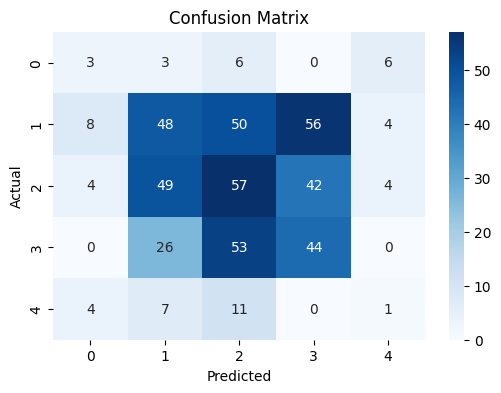

In [96]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [97]:
# Classification Report
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.16      0.17      0.16        18
           1       0.36      0.29      0.32       166
           2       0.32      0.37      0.34       156
           3       0.31      0.36      0.33       123
           4       0.07      0.04      0.05        23

    accuracy                           0.31       486
   macro avg       0.24      0.24      0.24       486
weighted avg       0.31      0.31      0.31       486



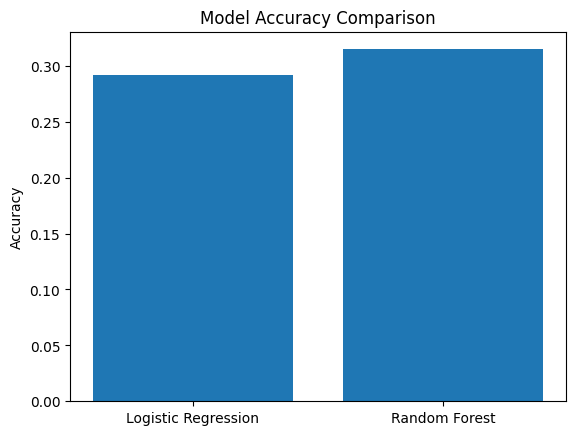

In [99]:
# Model Accuracy Comparison Chart
models = ['Logistic Regression','Random Forest']
scores = [lr_accuracy, rf_accuracy]
plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

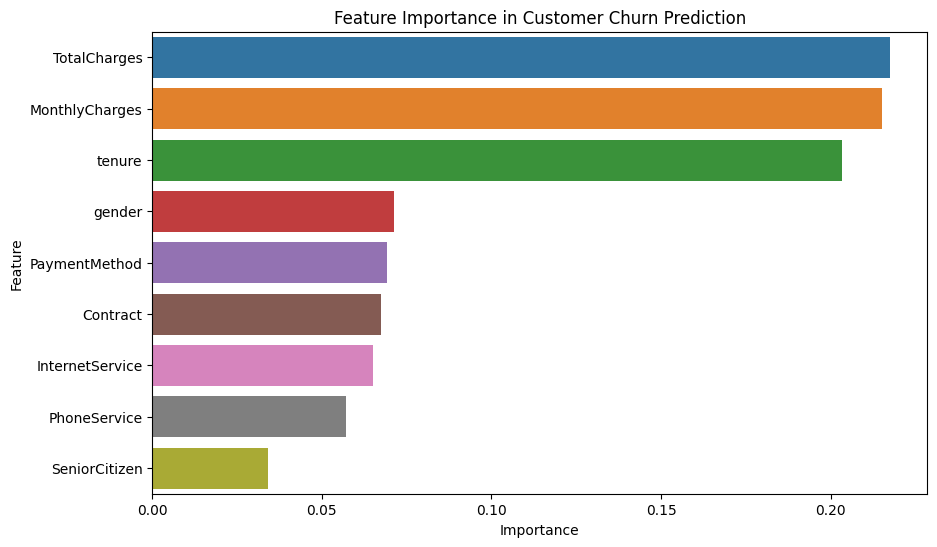

In [101]:
# Feature Importance Plot
importances = rf_model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance in Customer Churn Prediction")
plt.show()

In [102]:
# Saving Processed Dataset
df.to_csv("clean_telecom_customer_churn.csv", index=False)